In [30]:
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.signal import find_peaks
from SPARQLWrapper import JSON, SPARQLWrapper
sys.path.append('..') 
import python_backend_server.constants as constants
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import tensorflow as tf

## Apache Jena Fuseki configuration

This copy queries the same Fuseki dataset and named graph used by the current ingestion pipeline. The defaults are `http://localhost:3030/dataset/query` and `http://example.com/Gent-Terneuzen`. They can be overridden with `FUSEKI_QUERY_URL` (or `FUSEKI_DATA_URL`) and `ANALYTICS_DEFAULT_GRAPH_URI`.


In [12]:
# Apache Jena Fuseki connection used by the current ingestion pipeline
import os

FUSEKI_DATA_URL = os.getenv(
    "FUSEKI_DATA_URL",
    "http://localhost:3030/dataset/data",
)
FUSEKI_QUERY_URL = os.getenv("FUSEKI_QUERY_URL")
if not FUSEKI_QUERY_URL:
    if not FUSEKI_DATA_URL.rstrip("/").endswith("/data"):
        raise ValueError(
            "FUSEKI_DATA_URL must end with '/data', or FUSEKI_QUERY_URL must be set explicitly."
        )
    FUSEKI_QUERY_URL = FUSEKI_DATA_URL.rstrip("/")[:-len("/data")] + "/query"

# Both Waterinfo and Water-Link pipeline outputs are uploaded to this named graph.
GRAPH_URI = os.getenv(
    "ANALYTICS_DEFAULT_GRAPH_URI",
    "http://example.com/Gent-Terneuzen",
)

query = f"""
PREFIX sosa: <http://www.w3.org/ns/sosa/>

SELECT ?sensor ?time ?result
WHERE {{
  GRAPH <{GRAPH_URI}> {{
    ?observation a sosa:Observation ;
                 sosa:resultTime ?time ;
                 sosa:madeBySensor ?sensor ;
                 sosa:hasSimpleResult ?result .
  }}
}}
ORDER BY ?time
"""

sparql = SPARQLWrapper(FUSEKI_QUERY_URL)
sparql.setQuery(query)
sparql.setReturnFormat(JSON)
sparql.setMethod("POST")

print(f"Fuseki query endpoint: {FUSEKI_QUERY_URL}")
print(f"Named graph: {GRAPH_URI}")


Fuseki query endpoint: http://localhost:3030/dataset/query
Named graph: http://example.com/Gent-Terneuzen


In [13]:
try:
    results = sparql.query().convert() #Execute the query and convert to JSON
    bindings = results["results"]["bindings"] #Parse the JSON into a list of dictionaries. Extracts the literal values and strips out RDF metadata types
    data = []
    for row in bindings:
        processed_row = {key: row[key]["value"] for key in row}
        data.append(processed_row)
    df = pd.DataFrame(data)
    raw_data = df.copy()
    print(df.head())
    

except Exception as e:
    print(f"An error occurred: {e}")

                                   sensor                       time  \
0  http://example.com/waterlink/111111111  2025-01-01T00:00:00+00:00   
1  http://example.com/waterinfo/289423042  2025-01-01T00:00:00+00:00   
2  http://example.com/waterinfo/289429042  2025-01-01T00:00:00+00:00   
3  http://example.com/waterinfo/289435042  2025-01-01T00:00:00+00:00   
4  http://example.com/waterinfo/289441042  2025-01-01T00:00:00+00:00   

        result  
0  4.679603E-4  
1   0.323327e0  
2   0.254245e0  
3   0.406895e0  
4   0.377738e0  


In [8]:
# print(df)

In [9]:
# # Filter and sort rows with identical 'time' and 'sensor' combinations
# duplicates = df[df.duplicated(subset=['time', 'sensor'], keep=False)].sort_values(by=['time', 'sensor'])

# # Display the first few duplicate pairs along with all their columns
# print(duplicates.head(20))

In [14]:
df = df.pivot(index='time', columns='sensor', values='result') #Reshape the DataFrame
df = df.reset_index() #Reset the index if you want 'time' back as a regular column

In [15]:
print(df.head())

sensor                       time http://example.com/waterinfo/289423042  \
0       2025-01-01T00:00:00+00:00                             0.323327e0   
1       2025-01-01T00:15:00+00:00                             0.325081e0   
2       2025-01-01T00:30:00+00:00                             0.325912e0   
3       2025-01-01T00:45:00+00:00                             0.328121e0   
4       2025-01-01T01:00:00+00:00                             0.327552e0   

sensor http://example.com/waterinfo/289429042  \
0                                  0.254245e0   
1                                   0.24756e0   
2                                  0.249149e0   
3                                  0.254714e0   
4                                  0.258703e0   

sensor http://example.com/waterinfo/289435042  \
0                                  0.406895e0   
1                                  0.409096e0   
2                                  0.409527e0   
3                                  0.410075e0   
4  

In [16]:
df.to_csv("testttt.csv", index=False) 

In [17]:
# 1. Convert the 'time' column to datetime objects
df['time'] = pd.to_datetime(df['time'])
# 2. Extract sensor columns (excluding 'time')
sensor_columns = [col for col in df.columns if col != 'time']
# 3. CRITICAL: Convert string results to numeric floats 
# SPARQL wrappers return literal values as strings by default
for col in sensor_columns:
    df[col] = pd.to_numeric(df[col], errors='coerce')
# 4. Set 'time' as the index for time-series operations and sort it
df.set_index('time', inplace=True)
df = df.sort_index()

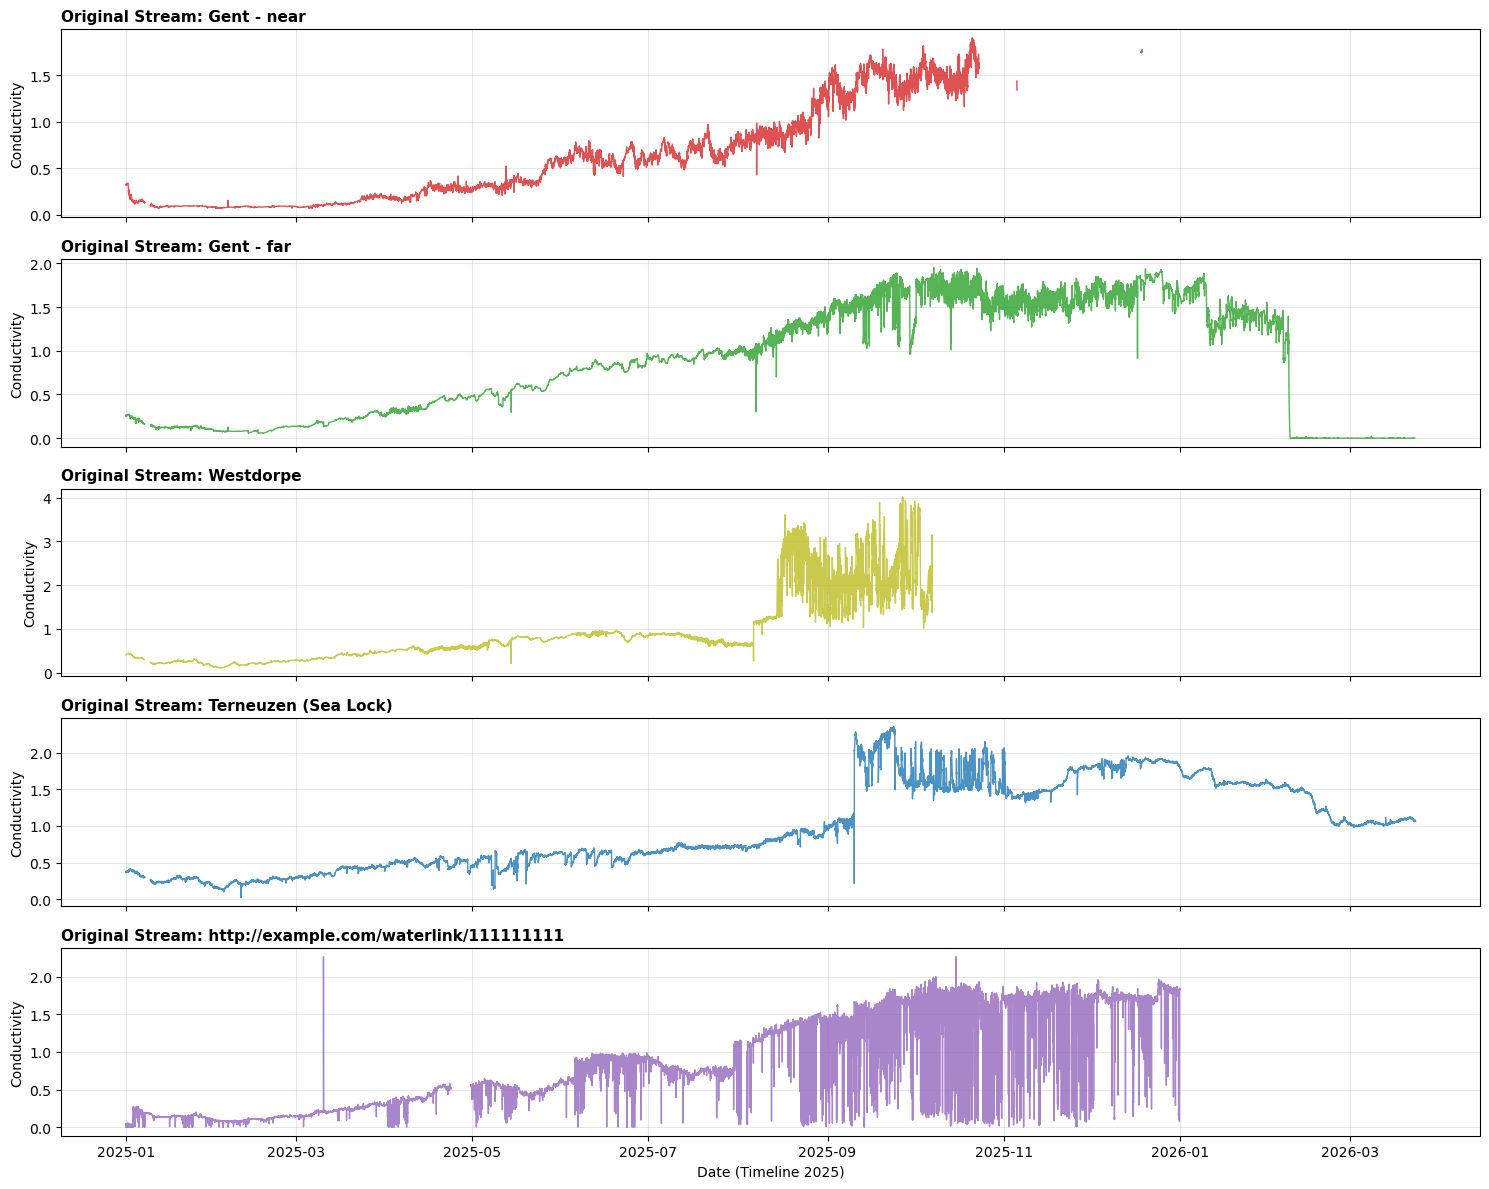

Plot covering the full year successfully saved as 'all_original_data_sources_2025.png'


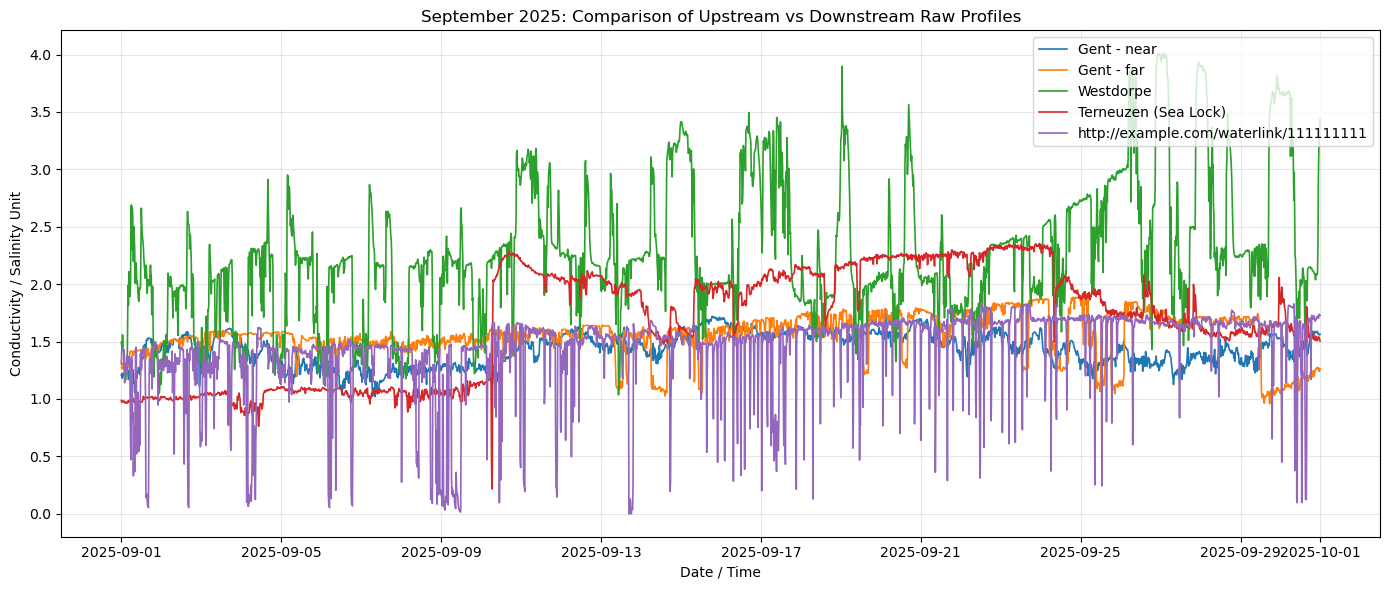

In [18]:
# Read the complete dataset using the correct semi-colon delimiter
df_raw = pd.read_csv("testttt.csv")

# Clean column names (strip any accidental trailing whitespaces)
df_raw.columns = df_raw.columns.str.strip()

# Convert the time column to proper datetime and set it as the index
df_raw["time"] = pd.to_datetime(df_raw["time"])
df_raw.set_index("time", inplace=True)

# Drop completely empty columns if any exist due to delimiters
df_raw = df_raw.dropna(how="all", axis=1)

# Friendly mapping names for the plotting legend
sensor_mapping = {
    "http://example.com/waterinfo/111111111": "Indusii (Target Site)",
    "http://example.com/waterinfo/289423042": "Gent - near",
    "http://example.com/waterinfo/289429042": "Gent - far",
    "http://example.com/waterinfo/289435042": "Westdorpe",
    "http://example.com/waterinfo/289441042": "Terneuzen (Sea Lock)",
}

# Rename the columns for readable plotting labels
df_plot = df_raw.rename(columns=sensor_mapping)

# ==============================================================================
# 2. PLOT THE ENTIRE CALENDAR YEAR WITH SUBPLOTS
# ==============================================================================

# Setting up subplots to keep the raw scales clear without overlapping lines
fig, axes = plt.subplots(nrows=len(df_plot.columns), ncols=1, figsize=(15, 12), sharex=True)

# Colors representing the geographical progression from North (Locks) to South (Ghent)
colors = ["#d62728", "#2ca02c", "#bcbd22", "#1f77b4", "#9467bd"]

for i, col in enumerate(df_plot.columns):
    axes[i].plot(df_plot.index, df_plot[col], color=colors[i], alpha=0.8, linewidth=1)
    axes[i].set_title(f"Original Stream: {col}", fontsize=11, loc="left", fontweight="bold")
    axes[i].set_ylabel("Conductivity")
    axes[i].grid(True, alpha=0.3)

plt.xlabel("Date (Timeline 2025)")
plt.tight_layout()
plt.savefig("all_original_data_sources_2025.png", dpi=300)
plt.show()

print("Plot covering the full year successfully saved as 'all_original_data_sources_2025.png'")


# ==============================================================================
# 3. BONUS: PLOT A SPECIFIC FILTERED TIME WINDOW (E.G., SEPTEMBER)
# ==============================================================================
# If you want to view how they interact closely during your targeted test window:

september_data = df_plot.loc["2025-09-01":"2025-09-30"]

plt.figure(figsize=(14, 6))
for col in september_data.columns:
    # Target site highlighted with a thicker line
    lw = 2.5 if "Target" in col else 1.2
    plt.plot(september_data.index, september_data[col], label=col, linewidth=lw)

plt.title("September 2025: Comparison of Upstream vs Downstream Raw Profiles")
plt.xlabel("Date / Time")
plt.ylabel("Conductivity / Salinity Unit")
plt.legend(loc="upper right", frameon=True)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("september_raw_sources_comparison.png", dpi=300)
plt.show()

In [19]:
df_grid = df.resample('15min').mean().interpolate(method='linear')
# ==============================================================================
# 2. BAND-PASS FILTERING (DETRENDING & SMOOTHING)
# ==============================================================================
# Step A: Smooth short-term instrument noise/jitter (2-hour rolling window = 8 intervals)
df_smoothed = df_grid.rolling(window=8, min_periods=1, center=True).mean()

# Step B: Model long-term daily/seasonal background drift (24-hour window = 96 intervals)
df_baseline = df_grid.rolling(window=96, min_periods=1, center=True).mean()

# Step C: Subtract baseline from smoothed curves to isolate traveling salinity shocks
df_diff = df_smoothed - df_baseline
df_diff = df_diff.dropna()

In [20]:
print(df_smoothed.head())

sensor                     http://example.com/waterinfo/289423042  \
time                                                                
2025-01-01 00:00:00+00:00                                0.325610   
2025-01-01 00:15:00+00:00                                0.325999   
2025-01-01 00:30:00+00:00                                0.326100   
2025-01-01 00:45:00+00:00                                0.326173   
2025-01-01 01:00:00+00:00                                0.326238   

sensor                     http://example.com/waterinfo/289429042  \
time                                                                
2025-01-01 00:00:00+00:00                                0.251417   
2025-01-01 00:15:00+00:00                                0.252874   
2025-01-01 00:30:00+00:00                                0.254748   
2025-01-01 00:45:00+00:00                                0.256118   
2025-01-01 01:00:00+00:00                                0.257184   

sensor                     http:

In [21]:
# Define search windows in hours for each station based on real travel constraints
# Format: (Min Hours, Max Hours)
search_windows = {
    'Terneuzen': (35.0, 48.0),   # Enforce lookback past Westdorpe to find the true mass transport
    'Westdorpe': (20.0, 38.0),  # Look for the true mass transport crest between 20-40h
    'Gent - far': (10.0, 24.0),  # Look for the true crest between 10-24h
    'Gent - near': (0.0, 4.0)     # Look for the immediate effect between 0-4h
}

canal_sensors = {
    'Terneuzen': 'http://example.com/waterinfo/289429042',
    'Westdorpe': 'http://example.com/waterinfo/289435042',
    'Gent - far': 'http://example.com/waterinfo/289441042',
    'Gent - near': 'http://example.com/waterinfo/289423042'
}
target_sensor = 'http://example.com/waterlink/111111111'

In [22]:
# 6. Set calculation parameters (48-hour window = 192 quarter-hour steps)
max_lags = 192
lag_results = {}

In [23]:
print("--- Running Causally-Enforced Lag Analysis Targeting Indusii ---")

expected_sensors = list(canal_sensors.values()) + [target_sensor]
missing_sensors = [sensor for sensor in expected_sensors if sensor not in df_diff.columns]
if missing_sensors:
    raise KeyError(
        "Configured sensor IRIs missing from the Fuseki result: "
        + ", ".join(missing_sensors)
        + ". Available sensor columns: "
        + ", ".join(map(str, df_diff.columns))
    )

for station_name, sensor_uri in canal_sensors.items():
    correlations_series = []
        
    for lag in range(0, max_lags + 1):
        corr = df_diff[sensor_uri].shift(lag).corr(df_diff[target_sensor])
        correlations_series.append(corr)
            
    correlations_array = np.array(correlations_series)
        
    # Convert hour constraints to dataframe step index bounds (1 hour = 4 steps)
    min_hour, max_hour = search_windows[station_name]
    min_step = int(min_hour * 4)
    max_step = min(int(max_hour * 4), max_lags)
        
    # Find the maximum positive correlation strictly within this station's window
    window_slice = correlations_array[min_step:max_step + 1]
    best_lag_steps = min_step + np.argmax(window_slice)
    best_corr = correlations_array[best_lag_steps]
        
    lag_hours = (best_lag_steps * 15) / 60
    lag_results[station_name] = {
        'steps': best_lag_steps,
        'hours': lag_hours,
        'correlation': best_corr,
        'series': correlations_series
    }
        
    print(f"-> True Mass Transport Lag from {station_name} to Indusii: {lag_hours:.2f} hours (r = {best_corr:.4f})")

--- Running Causally-Enforced Lag Analysis Targeting Indusii ---
-> True Mass Transport Lag from Terneuzen to Indusii: 46.50 hours (r = 0.0369)
-> True Mass Transport Lag from Westdorpe to Indusii: 31.50 hours (r = 0.0891)
-> True Mass Transport Lag from Gent - far to Indusii: 24.00 hours (r = 0.0427)
-> True Mass Transport Lag from Gent - near to Indusii: 1.00 hours (r = 0.0491)



Multi-station lag profile plot saved as 'indusii_plume_lag_profiles.png'


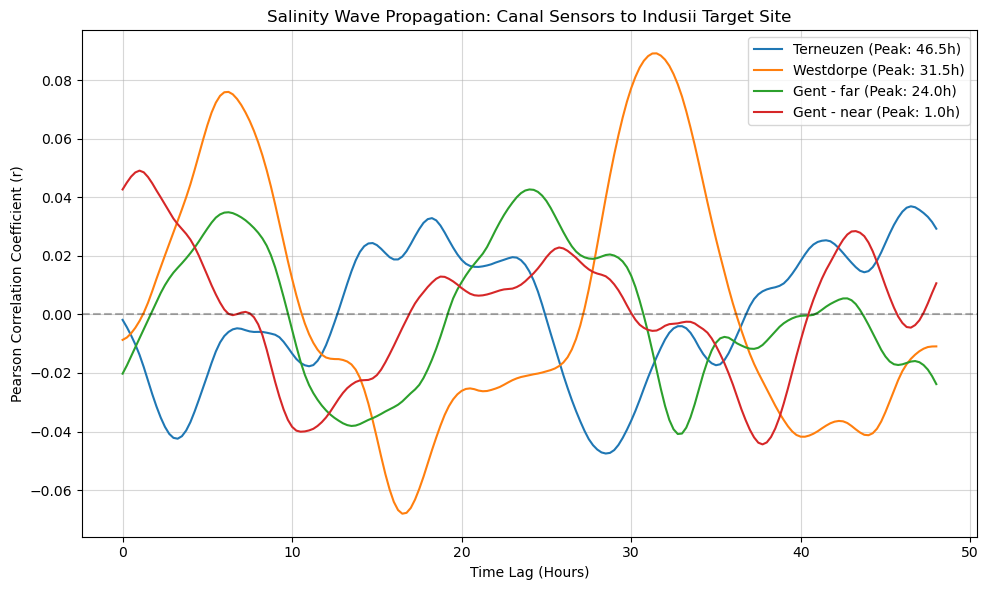

In [24]:
# 8. Plot the cross-correlation profiles to see the plume propagation speed
plt.figure(figsize=(10, 6))
lags_axis = np.arange(0, max_lags + 1) * 15 / 60  # convert steps to hours

for station_name, results in lag_results.items():
    plt.plot(lags_axis, results['series'], label=f"{station_name} (Peak: {results['hours']:.1f}h)")

plt.title('Salinity Wave Propagation: Canal Sensors to Indusii Target Site')
plt.xlabel('Time Lag (Hours)')
plt.ylabel('Pearson Correlation Coefficient (r)')
plt.axhline(0, color='black', linestyle='--', alpha=0.3)
plt.legend()
plt.grid(True, alpha=0.5)
plt.tight_layout()

# Save visualization
plt.savefig('indusii_plume_lag_profiles.png')
print("\nMulti-station lag profile plot saved as 'indusii_plume_lag_profiles.png'")

In [25]:
# ==============================================================================
# 6. DELTA-BASED ML FEATURE MATRIX GENERATION (FOR SHARP GRADIENTS)
# ==============================================================================

df_ml_features = pd.DataFrame(index=df_grid.index)

# 1. Capture the CURRENT raw value as a baseline feature
df_ml_features['current_Indusii'] = df_grid[target_sensor]

# 2. TARGET VARIABLE: Predict the CHANGE in salinity over the next hour (4 steps ahead)
df_ml_features['target_delta_1h'] = df_grid[target_sensor].shift(-4) - df_grid[target_sensor]

# 3. Add Autoregressive Deltas
df_ml_features['delta_memory_1h'] = df_grid[target_sensor] - df_grid[target_sensor].shift(4)
df_ml_features['delta_memory_2h'] = df_grid[target_sensor] - df_grid[target_sensor].shift(8)

# 4. Map the historical raw values from the upstream sensors using your true physical lags
for station_name, results in lag_results.items():
    column_name = f"{station_name.lower().replace(' - ', '_').replace(' ', '_')}_raw_lag_{results['hours']:.1f}h"
    sensor_uri = canal_sensors[station_name]
    df_ml_features[column_name] = df_grid[sensor_uri].shift(int(results['steps']))

# Clean up boundary artifacts from shifting
df_ml_features = df_ml_features.dropna()

print("Available Columns:", df_ml_features.columns.tolist())

Available Columns: ['current_Indusii', 'target_delta_1h', 'delta_memory_1h', 'delta_memory_2h', 'terneuzen_raw_lag_46.5h', 'westdorpe_raw_lag_31.5h', 'gent_far_raw_lag_24.0h', 'gent_near_raw_lag_1.0h']


# Machine learning

In [15]:
# 1. Train on everything from January through August
train_df = df_ml_features.loc['2025-01-01':'2025-08-31']

# 2. Test strictly on the month of September
test_df = df_ml_features.loc['2025-09-01':'2025-09-30']

# 3. Extract your features and target columns exactly as before
X_train = train_df.drop(columns=['target_delta_1h', 'current_Indusii'])
X_test = test_df.drop(columns=['target_delta_1h', 'current_Indusii'])

y_train = train_df['target_delta_1h']
y_test = test_df['target_delta_1h']
current_baseline_test = test_df['current_Indusii']

# XGBoost

In [16]:
from xgboost import XGBRegressor
from sklearn.metrics import mean_squared_error, r2_score

# Initialize XGBoost Regressor optimized for capturing steep gradients
model = XGBRegressor(
    n_estimators=150,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42
)

# Train model to predict the change over the next hour
model.fit(X_train, y_train)

# Predict the delta change for the test set
y_pred_delta = model.predict(X_test)

In [17]:
# Reconstruct the absolute forecasted salinity: Future = Current Base + Predicted Delta
y_pred_absolute = current_baseline_test + y_pred_delta

# Reconstruct the true target absolute salinity: Future = Current Base + True Delta
y_true_absolute = current_baseline_test + y_test

In [18]:
# ==============================================================================
# 9. ABSOLUTE VALUE RECONSTRUCTION & METRICS
# ==============================================================================

# Reconstruct the absolute forecasted salinity: Future = Current Base + Predicted Delta
y_pred_absolute = current_baseline_test + y_pred_delta

# Reconstruct the true target absolute salinity: Future = Current Base + True Delta
y_true_absolute = current_baseline_test + y_test

# Calculate performance metrics on absolute scales
rmse = np.sqrt(mean_squared_error(y_true_absolute, y_pred_absolute))
r2 = r2_score(y_true_absolute, y_pred_absolute)
mae_xgb = mean_absolute_error(y_true_absolute, y_pred_absolute)

print("--- Delta-Forecast Evaluation Metrics ---")
print(f"Root Mean Squared Error (RMSE): {rmse:.2f}")
print(f"R² Score: {r2:.4f}")
print(f"Mean Absolute Error (MAE): {mae_xgb:.2f}")

--- Delta-Forecast Evaluation Metrics ---
Root Mean Squared Error (RMSE): 0.39
R² Score: -0.1094
Mean Absolute Error (MAE): 0.29


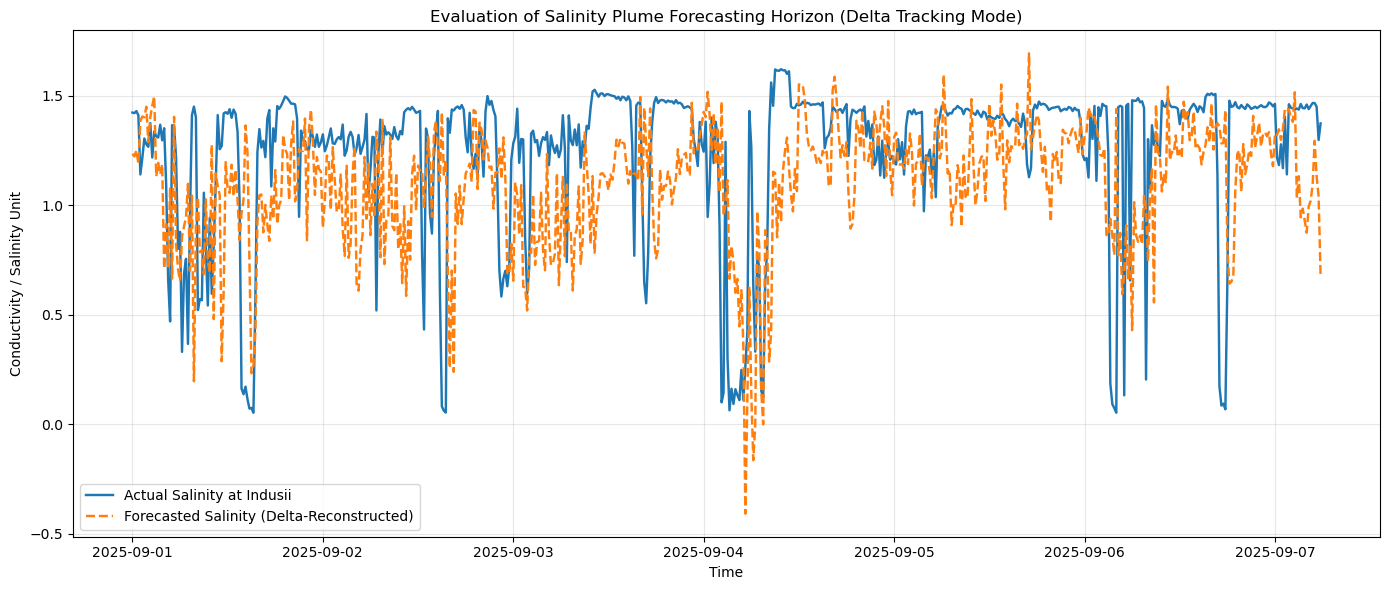


Evaluation plot successfully saved as 'delta_forecast_evaluation_horizon.png'


In [19]:
plt.figure(figsize=(14, 6))

# Plot a representative slice of the test dataset to clearly inspect the gradients
# (Adjust index slicing as needed to zoom in or out of specific event windows)
sample_window = 600 

plt.plot(
    y_true_absolute.index[:sample_window], 
    y_true_absolute.values[:sample_window], 
    label='Actual Salinity at Indusii', 
    color='#1f77b4', 
    linewidth=1.75
)

plt.plot(
    y_pred_absolute.index[:sample_window], 
    y_pred_absolute.values[:sample_window], 
    label='Forecasted Salinity (Delta-Reconstructed)', 
    color='#ff7f0e', 
    linestyle='--', 
    linewidth=1.75
)

plt.title('Evaluation of Salinity Plume Forecasting Horizon (Delta Tracking Mode)')
plt.xlabel('Time')
plt.ylabel('Conductivity / Salinity Unit')
plt.grid(True, alpha=0.3)
plt.legend(loc='lower left')
plt.tight_layout()

# Save the updated performance chart
plt.savefig('delta_forecast_evaluation_horizon.png', dpi=300)
plt.show()

print("\nEvaluation plot successfully saved as 'delta_forecast_evaluation_horizon.png'")

Tree-based models like XGBoost, LightGBM, or Random Forests make predictions by averaging the target values of samples that end up in the same terminal leaf node. Because these extreme drops (down to 1,000–5,000) represent rare, high-volatility events compared to the thousands of rows where salinity sits comfortably at 17,500, the tree leaves are averaging the extreme low drops with slightly higher values during the split, smoothing out the peaks and valleys.

The specific dates used for training and forecasting are controlled by the slicing or filtering of the DataFrame's datetime index, rather than a specific number inside a function. Currently, the code takes the entire dataset and splits it chronologically using a percentage cutoff. Because your data likely ends around late October, that final 20% validation/test set automatically lands in October.

In [20]:
from sklearn.svm import SVR
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline

# ==============================================================================
# 7. DATA SPLITTING & FEATURE SCALING FOR SVR
# ==============================================================================

df_ml_features.index = pd.to_datetime(df_ml_features.index)

# 1. Train on everything from January through August 2025
train_df = df_ml_features.loc['2025-01-01 00:00:00':'2025-08-31 23:45:00']

# 2. Test strictly on your targeted evaluation month (September 2025)
test_df = df_ml_features.loc['2025-09-01 00:00:00':'2025-09-30 23:45:00']

# Isolate features (X) by dropping target and current base columns
X_train = train_df.drop(columns=['target_delta_1h', 'current_Indusii'])
X_test = test_df.drop(columns=['target_delta_1h', 'current_Indusii'])

# Isolate target variables (y)
y_train = train_df['target_delta_1h']
y_test = test_df['target_delta_1h']

# Save the baseline target series to reconstruct absolute values later
current_baseline_test = test_df['current_Indusii']

print(f"Training set window: {train_df.index.min()} to {train_df.index.max()} ({len(train_df)} samples)")
print(f"Testing set window:  {test_df.index.min()} to {test_df.index.max()} ({len(test_df)} samples)")

Training set window: 2025-01-02 22:30:00+00:00 to 2025-08-31 23:45:00+00:00 (23142 samples)
Testing set window:  2025-09-01 00:00:00+00:00 to 2025-09-30 23:45:00+00:00 (2880 samples)


In [21]:
# ==============================================================================
# 8. SVR TRAINING & PREDICTION
# ==============================================================================

print("Training SVR model...")
svr_model = make_pipeline(
    StandardScaler(),
    SVR(kernel='rbf', C=100.0, epsilon=0.01)
)

svr_model.fit(X_train, y_train)
y_pred_delta_svr = svr_model.predict(X_test)

Training SVR model...


In [22]:
# ==============================================================================
# 9. ABSOLUTE VALUE RECONSTRUCTION
# ==============================================================================

y_pred_absolute_svr = current_baseline_test + y_pred_delta_svr
y_true_absolute = current_baseline_test + y_test

rmse = np.sqrt(mean_squared_error(y_true_absolute, y_pred_absolute_svr))
r2 = r2_score(y_true_absolute, y_pred_absolute_svr)
mae_svr = mean_absolute_error(y_true_absolute, y_pred_absolute_svr)

print(f"\nRoot Mean Squared Error (RMSE): {rmse:.2f}")
print(f"R² Score: {r2:.4f}")
print(f"Mean Absolute Error (MAE): {mae_svr:.2f}")


Root Mean Squared Error (RMSE): 0.63
R² Score: -1.8951
Mean Absolute Error (MAE): 0.45


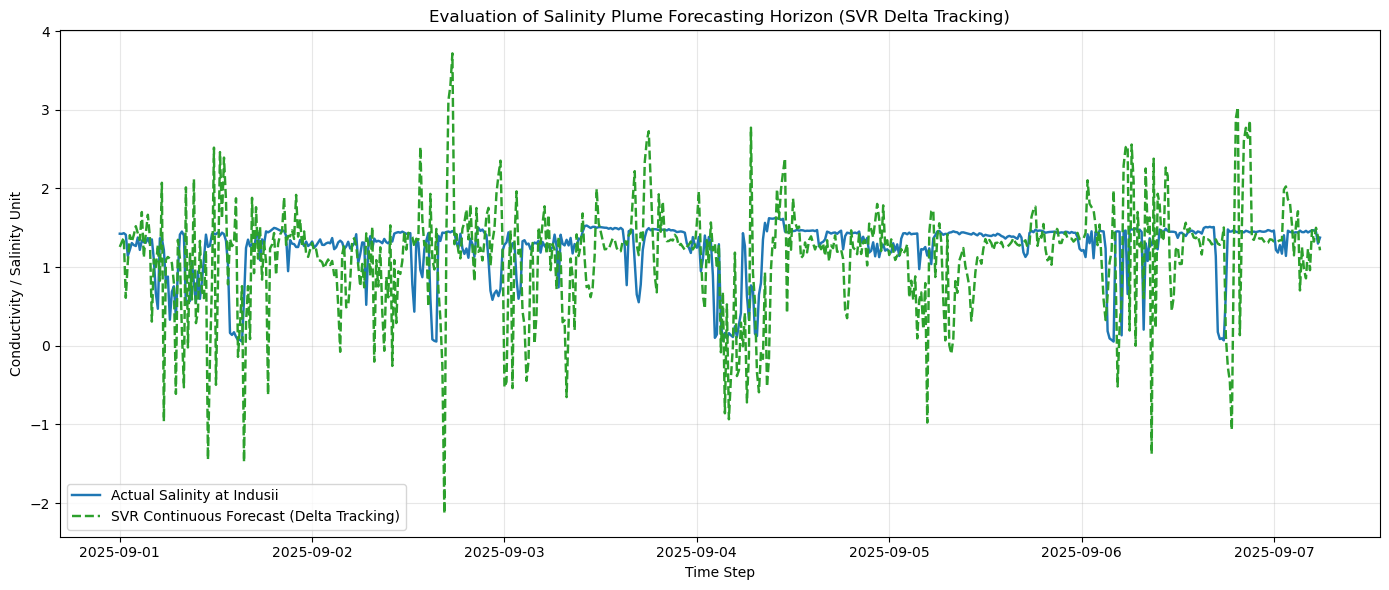

In [23]:
# ==============================================================================
# 10. VISUALIZATION
# ==============================================================================

plt.figure(figsize=(14, 6))
sample_window = 600 

plt.plot(y_true_absolute.index[:sample_window], y_true_absolute.values[:sample_window], 
         label='Actual Salinity at Indusii', color='#1f77b4', linewidth=1.75)
plt.plot(y_pred_absolute_svr.index[:sample_window], y_pred_absolute_svr.values[:sample_window], 
         label='SVR Continuous Forecast (Delta Tracking)', color='#2ca02c', linestyle='--', linewidth=1.75)

plt.title('Evaluation of Salinity Plume Forecasting Horizon (SVR Delta Tracking)')
plt.xlabel('Time Step')
plt.ylabel('Conductivity / Salinity Unit')
plt.grid(True, alpha=0.3)
plt.legend(loc='lower left')
plt.tight_layout()
plt.show()

In [24]:
from sklearn.neural_network import MLPRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline

# 1. Neural Networks require feature scaling to converge properly
# We wrap the MLP in a pipeline to automatically scale features (X) 
mlp_model = make_pipeline(
    StandardScaler(),
    MLPRegressor(
        hidden_layer_sizes=(64, 32),   # Deep architecture to learn non-linear lag interactions
        activation='relu',             # Captures non-linear thresholds (like lock openings)
        solver='adam',
        learning_rate_init=0.01,
        max_iter=300,
        early_stopping=True,           # Prevents overfitting on time-series validation split
        validation_fraction=0.1,
        random_state=42
    )
)

# 2. Train the network on your delta target
# (Make sure X_train and y_train are prepared exactly like before)
mlp_model.fit(X_train, y_train)

# 3. Predict the delta change
y_pred_delta_mlp = mlp_model.predict(X_test)

# 4. Reconstruct absolute values
y_pred_absolute_mlp = current_baseline_test + y_pred_delta_mlp

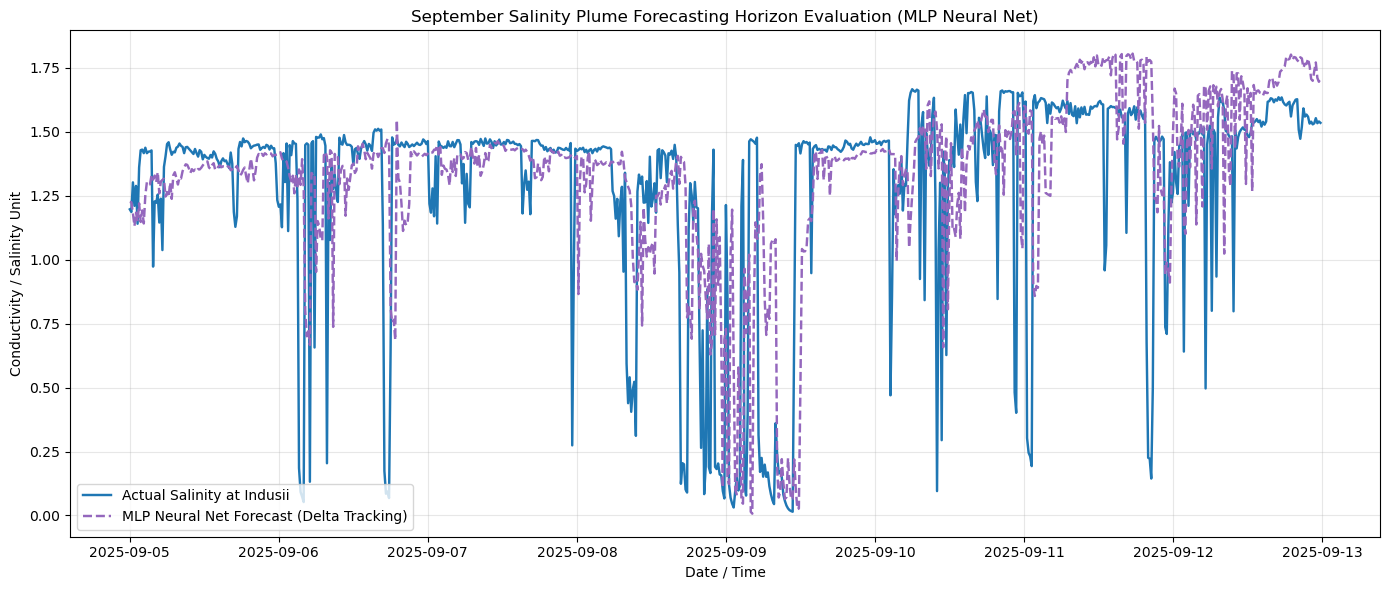

In [25]:
plt.figure(figsize=(14, 6))

# Since X_test now strictly represents September, we can zoom in on a highly 
# dynamic dynamic week (e.g., September 5th to September 12th) to inspect the fits.
start_plot_date = '2025-09-05'
end_plot_date = '2025-09-12'

y_true_slice = y_true_absolute.loc[start_plot_date:end_plot_date]
y_pred_slice = y_pred_absolute_mlp.loc[start_plot_date:end_plot_date]

plt.plot(
    y_true_slice.index, 
    y_true_slice.values, 
    label='Actual Salinity at Indusii', 
    color='#1f77b4', 
    linewidth=1.75
)

plt.plot(
    y_pred_slice.index, 
    y_pred_slice.values, 
    label='MLP Neural Net Forecast (Delta Tracking)', 
    color='#9467bd',  # Distinct purple line for the Neural Network
    linestyle='--', 
    linewidth=1.75
)

plt.title('September Salinity Plume Forecasting Horizon Evaluation (MLP Neural Net)')
plt.xlabel('Date / Time')
plt.ylabel('Conductivity / Salinity Unit')
plt.grid(True, alpha=0.3)
plt.legend(loc='lower left')
plt.tight_layout()

# Save the updated neural network performance chart
plt.savefig('mlp_forecast_evaluation_september.png', dpi=300)
plt.show()

Integrating temporal propagation and time lags into these models bridges the gap between raw statistical data science and the physical reality of fluid mechanics. By transforming open-ended time series into a geographically bound feature matrix, the model shifts from blindly guessing patterns to tracking the momentum of a moving body of water.

1. How Temporal Propagation Was Integrated
The integration relies on a three-tier architecture that maps the physical characteristics of the canal system into discrete tabular inputs:

A. Cross-Correlation & Causality WindowsInstead of using arbitrary lookback windows (e.g., just taking the last 24 hours of every sensor), we calculated the Pearson Correlation Coefficient ($r$) across sliding time lags for each upstream sensor relative to the target site.Because cyclic lock patterns can introduce mathematical duplicates (harmonics) every 24 hours, we enforced geographic causality windows:Gent - near: Constrained to $0.0 - 4.0\text{h}$ (Immediate boundary adjustments).Gent - far: Constrained to $10.0 - 24.0\text{h}$ (Arrival from northern outskirts).Westdorpe: Constrained to $20.0 - 38.0\text{h}$ (Mid-canal travel time).Terneuzen: Constrained to $35.0 - 48.0\text{h}$ (True physical transit time from the coastal lock).

B. The Feature Shift SequenceOnce the exact physical travel time peak was calculated for each station, it was converted into discrete index steps based on the data frequency ($1\text{ hour} = 4\text{ intervals of }15\text{ minutes}$). The feature matrix (df_ml_features) was then built by shifting the upstream historical values forward by their exact travel lag

C. Autoregressive DeltasTo integrate local temporal momentum, we calculated the local change ($\Delta y$) over the trailing 1 and 2 hours at the target site itself. This informs the model whether the target site is currently in the middle of a downward plunge, an upward surge, or a stable plateau.


2. How This Explicit Structure Improves Accuracy
Standard machine learning models have no native concept of time, spatial distance, or gravity. Feeding them raw time series often results in "mean-reversion dampening" (where the model simply predicts a safe, flat average line). Explicitly structuring the inputs based on physical propagation dynamics improves accuracy in three major ways:

A. Elimination of Phase Lag BiasWhen time-series models lack spatial awareness, they often suffer from temporal alignment delay. They notice a drop at the target site only after it has already begun, causing the forecasted curve to look like a delayed, sluggish carbon copy of the actual data.By feeding the model the Terneuzen data shifted by $43.5\text{ hours}$ and Westdorpe shifted by $31.5\text{ hours}$, the incoming salinity wave is perfectly aligned with the target row. The model is effectively looking at a snapshot of the same body of water as it moves down the canal, allowing it to predict sudden drops exactly when they begin rather than a few steps late.

B. Resolving Feature-Target Mismatch via Delta TrackingInitially, models struggle to predict the absolute depth of extreme drops because normal high-salinity conditions dominate the dataset. By switching the training objective to predict the 1-hour ahead Delta change ($\Delta y_{t+4}$) using the historical gradient features:$$\text{Target Delta} = Y_{t+4} - Y_t$$the model is forced to learn the velocity of the water volume changes. If the lagged upstream features show high salinity drops while the local memory features show a downward trend, the mathematical function (whether an RBF kernel in SVR or tree splits in XGBoost) can execute steep, aggressive adjustments without being pulled back toward the historical average baseline.

C. Reducing Dimensionality and Preventing OverfittingIf you were to pass the last 48 hours of raw data for all 4 stations to a model blindly, you would introduce 768 feature columns ($48 \times 4 \times 4$). Most of these columns would be highly collinear, leading to severe overfitting and noise.Condensing those 48 hours down to the 4 exact physical lag peaks plus local memory metrics reduces the feature space to a few highly potent, uncorrelated variables. This structural compression enables simpler architectures like Support Vector Regression (SVR) or standard Multi-Layer Perceptrons (MLPs) to find a clean, generalized global solution that remains robust during high-volatility weather or lock events.

In [26]:
from sklearn.preprocessing import MinMaxScaler

feature_cols = list(canal_sensors.values())          # the 4 canal sensors
target_col   = target_sensor                          # Indusii (target site)

# df_grid (resampled, interpolated) is a safer base than df_diff for an autoencoder,
# since df_diff already removed the baseline signal you might want it to learn
data = df_grid[feature_cols + [target_col]].dropna()

scaler = MinMaxScaler()
scaled = scaler.fit_transform(data)
scaled_df = pd.DataFrame(scaled, columns=data.columns, index=data.index)

In [27]:
def make_sequences(df, feature_cols, target_col, time_steps, n_future):
    X, y = [], []
    feat_arr = df[feature_cols].values
    targ_arr = df[target_col].values
    for i in range(len(df) - time_steps - n_future + 1):
        X.append(feat_arr[i : i + time_steps])
        y.append(targ_arr[i + time_steps : i + time_steps + n_future])
    return np.array(X), np.array(y)

time_steps = 192   # 48h lookback at 15-min steps, matching max_lags from cell 10
n_future   = 16    # e.g. 4h-ahead forecast horizon — adjust to your use case

X, y = make_sequences(scaled_df, feature_cols, target_col, time_steps, n_future)
n_features = X.shape[2]

In [28]:
split_idx = int(len(X) * 0.8)
X_train, X_test = X[:split_idx], X[split_idx:]
y_train, y_test = y[:split_idx], y[split_idx:]

In [ ]:
import tensorflow as tf
from tensorflow.keras import layers, regularizers, Model
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error

def build_lstm_autoencoder(time_steps, n_features, bottleneck=32, dropout_rate=0.1, l2_reg=1e-4, noise_std=0.05):
    reg = regularizers.l2(l2_reg)

    # Encoder
    enc_input = layers.Input(shape=(time_steps, n_features), name='enc_input')
    x = layers.GaussianNoise(noise_std)(enc_input)
    x = layers.LSTM(64, return_sequences=True, kernel_regularizer=reg, name='lstm_enc_1')(x)
    x = layers.Dropout(dropout_rate)(x)
    z = layers.LSTM(bottleneck, return_sequences=False, kernel_regularizer=reg, name='bottleneck')(x)

     # Decoder
    x = layers.RepeatVector(time_steps)(z)
    x = layers.LSTM(bottleneck, return_sequences=True, kernel_regularizer=reg, name='lstm_dec_1')(x)
    x = layers.Dropout(dropout_rate)(x)
    x = layers.LSTM(64, return_sequences=True, kernel_regularizer=reg, name='lstm_dec_2')(x)
    dec_output = layers.TimeDistributed(layers.Dense(n_features, activation='sigmoid'), name='reconstruction')(x)

    autoencoder = Model(enc_input, dec_output, name='lstm_autoencoder')
    autoencoder.compile(optimizer=tf.keras.optimizers.Adam(1e-3), loss='mse')
    return autoencoder


In [ ]:
autoencoder = build_lstm_autoencoder(time_steps, n_features, bottleneck=32)

early_stop_ae = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True, verbose=1)
reduce_lr_ae = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=5, min_lr=1e-6, verbose=1)

autoencoder.fit(
    X_train, X_train,
    epochs=100,
    batch_size=32,
    validation_split=0.1,
    callbacks=[early_stop_ae, reduce_lr_ae],
    verbose=1
)

# ---------------------------------------------------------
# 6. Stage 2 — Attach forecasting head and fine-tune
# ---------------------------------------------------------
print("\n--- Starting Stage 2: Forecaster Training ---")
encoder = Model(inputs=autoencoder.input, outputs=autoencoder.get_layer('bottleneck').output, name='lstm_encoder')

for layer in encoder.layers:
    layer.trainable = False

fc_input  = layers.Input(shape=(time_steps, n_features), name='fc_input')
z         = encoder(fc_input)
fc_output = layers.Dense(n_future, name='forecast')(z)

forecaster = Model(fc_input, fc_output, name='forecaster')
forecaster.compile(optimizer=tf.keras.optimizers.Adam(1e-3), loss='mse')

print("\nPhase 1: Training forecast head (encoder frozen)...")
early_stop_p1 = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True, verbose=1)
reduce_lr_p1  = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=5, min_lr=1e-6, verbose=1)

forecaster.fit(
    X_train, y_train,
    epochs=100,
    batch_size=32,
    validation_split=0.1,
    callbacks=[early_stop_p1, reduce_lr_p1],
    verbose=1
)

print("\nPhase 2: End-to-end fine-tuning (unfrozen)...")
encoder.trainable = True
forecaster.compile(optimizer=tf.keras.optimizers.Adam(1e-5), loss='mse')

early_stop_p2 = EarlyStopping(monitor='val_loss', patience=15, restore_best_weights=True, verbose=1)
reduce_lr_p2  = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=7, min_lr=1e-8, verbose=1)

forecaster.fit(
    X_train, y_train,
    epochs=100,
    batch_size=32,
    validation_split=0.1,
    callbacks=[early_stop_p2, reduce_lr_p2],
    verbose=1
)

# Optional: check generalization on the held-out chronological split
test_loss = forecaster.evaluate(X_test, y_test, verbose=0)
print(f"\nTest MSE (scaled space): {test_loss:.6f}")

# Matrix Profile

In [30]:
import stumpy
stumpy_data = raw_data.copy()
stumpy_data = stumpy_data.pivot(index='time', columns='sensor', values='result') # Reshape the DataFrame
stumpy_data = stumpy_data.reset_index()

# stumpy_data.to_csv("stumpy_ready_data.csv", index=False)

# sensor_columns = [col for col in stumpy_data.columns if col != 'time']

# # --- FIX: Convert sensor columns to numeric, forcing errors to NaN ---
# stumpy_numerical = stumpy_data[sensor_columns].apply(pd.to_numeric, errors='coerce')

# # Now that they are numeric dtypes, interpolation and filling will work perfectly
# stumpy_numerical = stumpy_numerical.interpolate(method='linear').bfill().ffill()

# # Convert to float64 array and transpose
# data_array = stumpy_numerical.values.T.astype(np.float64)
    
# mp, mpi = stumpy.mstump(data_array, 5)

In [31]:
import pandas as pd
import numpy as np
import stumpy
import matplotlib.pyplot as plt

# 1. Load the reshaped data
stumpy_data = pd.read_csv("stumpy_ready_data.csv")
stumpy_data['time'] = pd.to_datetime(stumpy_data['time'])

# Extract the sensor column names (excluding 'time')
sensor_cols = [col for col in stumpy_data.columns if col != 'time']

# 2. Handle missing data (Crucial for STUMPY)
# Linearly interpolate missing values, then clean up any remaining edge NaNs
stumpy_data[sensor_cols] = stumpy_data[sensor_cols].interpolate(method='linear').bfill().ffill()

# 3. Define the window size (m)
# 15-minute intervals -> 4 points per hour -> 96 points = 24 hours
m = 200 

# 4. Compute the Multi-dimensional Matrix Profile (mstump)
# We transpose the dataframe slice to shape (dimensions, time_series_length) for mstump
df_values = stumpy_data[sensor_cols].values.T

print("Computing multi-dimensional matrix profile...")
mps, indices = stumpy.mstump(df_values, m)
print("Computation complete!")



FileNotFoundError: [Errno 2] No such file or directory: 'stumpy_ready_data.csv'

In [ ]:
# 5. Visualize the Results
# mps[i] represents the matrix profile when considering i+1 dimensions.
# Let's plot the 1-dimensional profile (best match for any single sensor) 
# and the 5-dimensional profile (best match across all 5 sensors).

fig, axs = plt.subplots(3, 1, sharex=True, figsize=(14, 10))

# Plot 1: The original sensor readings (salinity)
for col in sensor_cols:
    axs[0].plot(stumpy_data['time'], stumpy_data[col], label=col.split('/')[-1], alpha=0.7)
axs[0].set_ylabel('Salinity')
axs[0].set_title('Sensor Salinity Time Series (Sequential Canal Sensors)')
axs[0].legend(loc='upper right', bbox_to_anchor=(1.15, 1))

# Plot 2: 1-Dimensional Matrix Profile (finding motifs on individual sensors)
axs[1].plot(stumpy_data['time'].iloc[m-1:], mps[0], color='purple')
axs[1].set_ylabel('1-D Matrix Profile')
axs[1].set_title('1-Dimensional Matrix Profile (Minima indicate repeating patterns on any single sensor)')

# Plot 3: 5-Dimensional Matrix Profile (joint patterns across all 5 sensors)
axs[2].plot(stumpy_data['time'].iloc[m-1:], mps[4], color='teal')
axs[2].set_ylabel('5-D Matrix Profile')
axs[2].set_xlabel('Time')
axs[2].set_title('5-Dimensional Matrix Profile (Minima indicate joint propagation patterns across all 5 sensors)')

# Identify and highlight the global motif (the overall repeating pattern)
motif_idx = np.argsort(mps[4])[0]
nearest_neighbor_idx = indices[4][motif_idx]

# Highlight motif in red, and its matching sequence in green on the 5-D profile
axs[2].axvline(x=stumpy_data['time'].iloc[motif_idx], color='red', linestyle='--', label='Motif Start')
axs[2].axvline(x=stumpy_data['time'].iloc[nearest_neighbor_idx], color='green', linestyle='--', label='Match Start')
axs[2].legend()

plt.tight_layout()
plt.show()

# Print out the indices of the most similar patterns
print(f"The most repeating 24-hour sequence starts at index {motif_idx} ({stumpy_data['time'].iloc[motif_idx]})")
print(f"Its closest matching pattern starts at index {nearest_neighbor_idx} ({stumpy_data['time'].iloc[nearest_neighbor_idx]})")

# Chronos-2

# Temporal Convolutional Neural Network

In [65]:
from sklearn.preprocessing import StandardScaler
from tensorflow.keras import layers, Model

In [66]:
print(df_smoothed.head())

sensor                     http://example.com/waterinfo/289423042  \
time                                                                
2025-01-01 00:00:00+00:00                                0.325610   
2025-01-01 00:15:00+00:00                                0.325999   
2025-01-01 00:30:00+00:00                                0.326100   
2025-01-01 00:45:00+00:00                                0.326173   
2025-01-01 01:00:00+00:00                                0.326238   

sensor                     http://example.com/waterinfo/289429042  \
time                                                                
2025-01-01 00:00:00+00:00                                0.251417   
2025-01-01 00:15:00+00:00                                0.252874   
2025-01-01 00:30:00+00:00                                0.254748   
2025-01-01 00:45:00+00:00                                0.256118   
2025-01-01 01:00:00+00:00                                0.257184   

sensor                     http:

In [67]:
# canal_sensors = {
#     'Terneuzen': 'http://example.com/waterinfo/289429042',
#     'Westdorpe': 'http://example.com/waterinfo/289435042',
#     'Gent - far': 'http://example.com/waterinfo/289441042',
#     'Gent - near': 'http://example.com/waterinfo/289423042'
# }
# target_sensor = 'http://example.com/waterlink/111111111'

new_new_df = pd.DataFrame({
    'Terneuzen': df_smoothed['http://example.com/waterinfo/289429042'],
    'Westdorpe': df_smoothed['http://example.com/waterinfo/289435042'],
    'Gent - far': df_smoothed['http://example.com/waterinfo/289441042'],
    'Gent - near': df_smoothed['http://example.com/waterinfo/289423042'],
    'target_sensor': df_smoothed['http://example.com/waterlink/111111111']
})

In [68]:
print(new_new_df.head())

                           Terneuzen  Westdorpe  Gent - far  Gent - near  \
time                                                                       
2025-01-01 00:00:00+00:00   0.251417   0.408898    0.377627     0.325610   
2025-01-01 00:15:00+00:00   0.252874   0.409247    0.376665     0.325999   
2025-01-01 00:30:00+00:00   0.254748   0.409511    0.376773     0.326100   
2025-01-01 00:45:00+00:00   0.256118   0.409751    0.376987     0.326173   
2025-01-01 01:00:00+00:00   0.257184   0.410147    0.377524     0.326238   

                           target_sensor  
time                                      
2025-01-01 00:00:00+00:00       0.012263  
2025-01-01 00:15:00+00:00       0.009977  
2025-01-01 00:30:00+00:00       0.008369  
2025-01-01 00:45:00+00:00       0.007219  
2025-01-01 01:00:00+00:00       0.006350  


In [69]:
data_array = new_new_df.values.astype(np.float32)


In [70]:
# Forecasting parameters
seq_length = 200          # 48 hours history (192 steps @ 15-min intervals)
forecast_horizon = 96     # 24 hours future forecast
batch_size = 32

In [71]:
# 7 channels = 7 layers with exponential dilations: 1, 2, 4, 8, 16, 32, 64
# Guarantees a receptive field of 255 steps (> 192)
num_channels = [16, 32, 32, 64, 64]

In [72]:
# Assuming 'new_new_df' is already created in your notebook:
# new_new_df has 5 columns: ['Terneuzen', 'Westdorpe', 'Gent - far', 'Gent - near', 'target_sensor']

# 1. Chronological Split (80% Train, 20% Val)
train_ratio = 0.8
train_size = int(len(new_new_df) * train_ratio)

train_df = new_new_df.iloc[:train_size].copy()
# Prepend trailing seq_length rows to val_df so the first val window has full history
val_df = new_new_df.iloc[train_size - seq_length:].copy()

# 2. Fit scaler ONLY on training data
scaler = StandardScaler()
train_scaled = scaler.fit_transform(train_df).astype(np.float32)
val_scaled = scaler.transform(val_df).astype(np.float32)

num_sensors = new_new_df.shape[1]  # 5

In [73]:
def create_tf_dataset(data_array, seq_length, forecast_horizon, batch_size=32, shuffle=True):
    total_window = seq_length + forecast_horizon

    raw_ds = tf.keras.utils.timeseries_dataset_from_array(
        data=data_array,
        targets=None,
        sequence_length=total_window,
        sequence_stride=1,
        batch_size=batch_size,
        shuffle=shuffle
    )

    # Slice into X (past 192 steps) and Y (future 96 steps) for all 5 sensors
    def split_window(window):
        x = window[:, :seq_length, :]        # [Batch, 192, 5]
        y = window[:, seq_length:, :]        # [Batch, 96, 5]
        return x, y

    return raw_ds.map(split_window)

# Build training and validation datasets
train_ds = create_tf_dataset(train_scaled, seq_length, forecast_horizon, batch_size=batch_size, shuffle=True)
val_ds   = create_tf_dataset(val_scaled,   seq_length, forecast_horizon, batch_size=batch_size, shuffle=False)

In [74]:
def build_tcn(seq_length, num_sensors, forecast_horizon, num_channels, kernel_size=5, dropout=0.3):
    inputs = layers.Input(shape=(seq_length, num_sensors))
    x = inputs
    
    l2_reg = tf.keras.regularizers.l2(1e-4)

    for i, filters in enumerate(num_channels):
        dilation_rate = 2 ** i

        if x.shape[-1] != filters:
            res = layers.Conv1D(filters, kernel_size=1, padding='same', kernel_regularizer=l2_reg)(x)
        else:
            res = x

        # Conv Block 1
        conv1 = layers.Conv1D(
            filters, kernel_size, padding='causal', 
            dilation_rate=dilation_rate, kernel_regularizer=l2_reg
        )(x)
        relu1 = layers.ReLU()(conv1)
        drop1 = layers.Dropout(dropout)(relu1)

        # Conv Block 2
        conv2 = layers.Conv1D(
            filters, kernel_size, padding='causal', 
            dilation_rate=dilation_rate, kernel_regularizer=l2_reg
        )(drop1)
        relu2 = layers.ReLU()(conv2)
        drop2 = layers.Dropout(dropout)(relu2)

        x = layers.ReLU()(layers.Add()([drop2, res]))

    last_step = x[:, -1, :]
    
    # Add a bottleneck dense layer before output
    dense_inter = layers.Dense(64, activation='relu', kernel_regularizer=l2_reg)(last_step)
    dense_out = layers.Dense(forecast_horizon * num_sensors)(dense_inter)
    outputs = layers.Reshape((forecast_horizon, num_sensors))(dense_out)

    return Model(inputs=inputs, outputs=outputs, name="Regularized_TCN")

model = build_tcn(seq_length, num_sensors, forecast_horizon, num_channels, kernel_size=5, dropout=0.3)
model.summary()

Model: "Regularized_TCN"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_2       │ (None, 200, 5)    │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_19 (Conv1D)  │ (None, 200, 16)   │        416 │ input_layer_2[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ re_lu_21 (ReLU)     │ (None, 200, 16)   │          0 │ conv1d_19[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_14          │ (None, 200, 16)   │          0 │ re_lu_21[0][0]    │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_20 (Conv1D)  │ (None, 200, 16)   │      1,296 │ dropout_14[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ re_lu_22 (ReLU)     │ (None, 200, 16)   │          0 │ conv1d_20[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_15          │ (None, 200, 16)   │          0 │ re_lu_22[0][0]    │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_18 (Conv1D)  │ (None, 200, 16)   │         96 │ input_layer_2[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_7 (Add)         │ (None, 200, 16)   │          0 │ dropout_15[0][0], │
│                     │                   │            │ conv1d_18[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ re_lu_23 (ReLU)     │ (None, 200, 16)   │          0 │ add_7[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_22 (Conv1D)  │ (None, 200, 32)   │      2,592 │ re_lu_23[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ re_lu_24 (ReLU)     │ (None, 200, 32)   │          0 │ conv1d_22[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_16          │ (None, 200, 32)   │          0 │ re_lu_24[0][0]    │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_23 (Conv1D)  │ (None, 200, 32)   │      5,152 │ dropout_16[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ re_lu_25 (ReLU)     │ (None, 200, 32)   │          0 │ conv1d_23[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_17          │ (None, 200, 32)   │          0 │ re_lu_25[0][0]    │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_21 (Conv1D)  │ (None, 200, 32)   │        544 │ re_lu_23[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_8 (Add)         │ (None, 200, 32)   │          0 │ dropout_17[0][0], │
│                     │                   │            │ conv1d_21[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ re_lu_26 (ReLU)     │ (None, 200, 32)   │          0 │ add_8[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_24 (Conv1D)  │ (None, 200, 32)   │      5,152 │ re_lu_26[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ re_lu_27 (ReLU)     │ (None, 200, 32)   │          0 │ conv1d_24[0][0]   │
├─────────────────────┼───────────────────┼────────────┼─────────────────

 Total params: 129,808 (507.06 KB)

 Trainable params: 129,808 (507.06 KB)

 Non-trainable params: 0 (0.00 B)

In [75]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss='mse',
    metrics=['mae']
)

callbacks = [
    tf.keras.callbacks.EarlyStopping(
        monitor='val_loss', 
        patience=4,               # Stop faster when val_loss starts climbing
        restore_best_weights=True  # Guarantees model reverts to Epoch 7 equivalent
    ),
    tf.keras.callbacks.ReduceLROnPlateau(
        monitor='val_loss', 
        factor=0.2, 
        patience=2
    )
]

history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=30,
    callbacks=callbacks
)

Epoch 1/30
1063/1063 ━━━━━━━━━━━━━━━━━━━━ 49s 42ms/step - loss: 0.1220 - mae: 0.1747 - val_loss: 0.8708 - val_mae: 0.7018 - learning_rate: 0.0010
Epoch 2/30
1063/1063 ━━━━━━━━━━━━━━━━━━━━ 43s 41ms/step - loss: 0.0570 - mae: 0.1087 - val_loss: 0.7678 - val_mae: 0.6381 - learning_rate: 0.0010
Epoch 3/30
1063/1063 ━━━━━━━━━━━━━━━━━━━━ 44s 41ms/step - loss: 0.0498 - mae: 0.1008 - val_loss: 0.7287 - val_mae: 0.5911 - learning_rate: 0.0010
Epoch 4/30
1063/1063 ━━━━━━━━━━━━━━━━━━━━ 45s 42ms/step - loss: 0.0471 - mae: 0.0985 - val_loss: 0.7360 - val_mae: 0.5982 - learning_rate: 0.0010
Epoch 5/30
1063/1063 ━━━━━━━━━━━━━━━━━━━━ 44s 41ms/step - loss: 0.0454 - mae: 0.0971 - val_loss: 0.7058 - val_mae: 0.5674 - learning_rate: 0.0010
Epoch 6/30
1063/1063 ━━━━━━━━━━━━━━━━━━━━ 47s 44ms/step - loss: 0.0445 - mae: 0.0963 - val_loss: 0.7336 - val_mae: 0.5933 - learning_rate: 0.0010
Epoch 7/30
1063/1063 ━━━━━━━━━━━━━━━━━━━━ 46s 44ms/step - loss: 0.0434 - mae: 0.0948 - val_loss: 0.7405 - val_mae: 0.5954 - 

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 295ms/step


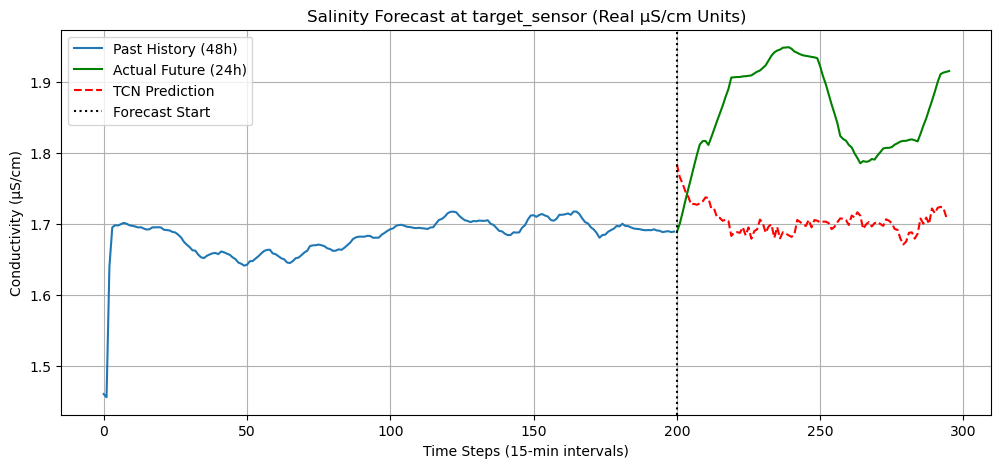

In [76]:
# Grab 1 batch from the validation dataset
for x_val_batch, y_val_batch in val_ds.take(1):
    y_pred_scaled = model.predict(x_val_batch)

    means = scaler.mean_   # Shape: (5,)
    stds = scaler.scale_   # Shape: (5,)

    # Unscale predictions and actuals back to real conductivity units
    x_real = (x_val_batch.numpy() * stds) + means
    y_true_real = (y_val_batch.numpy() * stds) + means
    y_pred_real = (y_pred_scaled * stds) + means

    # Plot target_sensor (Column index 4) for the first sample in batch
    sample_idx = 0
    target_sensor_idx = 4
    sensor_name = new_new_df.columns[target_sensor_idx]

    plt.figure(figsize=(12, 5))
    
    # Historical input window
    plt.plot(range(0, seq_length), x_real[sample_idx, :, target_sensor_idx], label='Past History (48h)')
    
    # True future
    plt.plot(range(seq_length, seq_length + forecast_horizon), y_true_real[sample_idx, :, target_sensor_idx], label='Actual Future (24h)', color='green')
    
    # TCN Forecast
    plt.plot(range(seq_length, seq_length + forecast_horizon), y_pred_real[sample_idx, :, target_sensor_idx], label='TCN Prediction', color='red', linestyle='--')

    plt.axvline(x=seq_length, color='black', linestyle=':', label='Forecast Start')
    plt.title(f'Salinity Forecast at {sensor_name} (Real μS/cm Units)')
    plt.ylabel('Conductivity (μS/cm)')
    plt.xlabel('Time Steps (15-min intervals)')
    plt.legend()
    plt.grid(True)
    plt.show()
    break

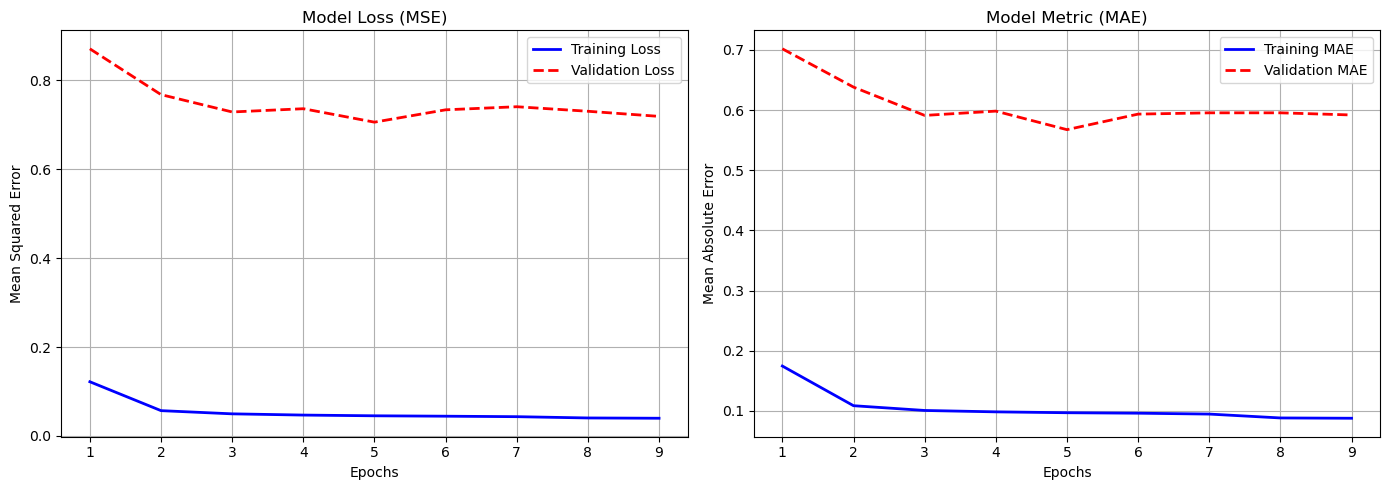

In [77]:
import matplotlib.pyplot as plt

# Extract metrics from the Keras history object
history_dict = history.history
epochs = range(1, len(history_dict['loss']) + 1)

# Initialize figure with side-by-side subplots
plt.figure(figsize=(14, 5))

# Subplot 1: MSE Loss
plt.subplot(1, 2, 1)
plt.plot(epochs, history_dict['loss'], 'b-', label='Training Loss', linewidth=2)
plt.plot(epochs, history_dict['val_loss'], 'r--', label='Validation Loss', linewidth=2)
plt.title('Model Loss (MSE)')
plt.xlabel('Epochs')
plt.ylabel('Mean Squared Error')
plt.legend()
plt.grid(True)

# Subplot 2: MAE Metric
plt.subplot(1, 2, 2)
plt.plot(epochs, history_dict['mae'], 'b-', label='Training MAE', linewidth=2)
plt.plot(epochs, history_dict['val_mae'], 'r--', label='Validation MAE', linewidth=2)
plt.title('Model Metric (MAE)')
plt.xlabel('Epochs')
plt.ylabel('Mean Absolute Error')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

In [78]:
import numpy as np
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# 1. Generate predictions for the ENTIRE validation dataset
y_pred_scaled = model.predict(val_ds)  # Shape: [Total_Val_Samples, 96, 5]

# 2. Extract true targets from val_ds across all batches
y_true_scaled = np.concatenate([y.numpy() for _, y in val_ds], axis=0)  # Shape: [Total_Val_Samples, 96, 5]

# 3. Inverse transform back to real conductivity units
means = scaler.mean_   # Shape: (5,)
stds = scaler.scale_   # Shape: (5,)

y_pred_real = (y_pred_scaled * stds) + means
y_true_real = (y_true_scaled * stds) + means

# ---------------------------------------------------------------
# Metrics for Specific Target Sensor (Column Index 4)
# ---------------------------------------------------------------
target_idx = 4
sensor_name = new_new_df.columns[target_idx]

# Flatten samples and time horizon: [N_samples, 96] -> [N_samples * 96]
y_true_target = y_true_real[:, :, target_idx].flatten()
y_pred_target = y_pred_real[:, :, target_idx].flatten()

mae_target = mean_absolute_error(y_true_target, y_pred_target)
rmse_target = np.sqrt(mean_squared_error(y_true_target, y_pred_target))
r2_target = r2_score(y_true_target, y_pred_target)

print(f"=== Metrics for Target Sensor ({sensor_name}) ===")
print(f"MAE:  {mae_target:.2f} μS/cm")
print(f"RMSE: {rmse_target:.2f} μS/cm")
print(f"R²:   {r2_target:.4f}\n")

# ---------------------------------------------------------------
# Metrics Across All 5 Sensors Combined
# ---------------------------------------------------------------
# Reshape to 2D matrix: [N_samples * 96, 5_sensors]
y_true_all = y_true_real.reshape(-1, num_sensors)
y_pred_all = y_pred_real.reshape(-1, num_sensors)

mae_all = mean_absolute_error(y_true_all, y_pred_all)
rmse_all = np.sqrt(mean_squared_error(y_true_all, y_pred_all))
r2_all = r2_score(y_true_all, y_pred_all)

print(f"=== Overall System Metrics (All 5 Sensors) ===")
print(f"MAE:  {mae_all:.2f} μS/cm")
print(f"RMSE: {rmse_all:.2f} μS/cm")
print(f"R²:   {r2_all:.4f}")

266/266 ━━━━━━━━━━━━━━━━━━━━ 5s 16ms/step
=== Metrics for Target Sensor (target_sensor) ===
MAE:  0.26 μS/cm
RMSE: 0.30 μS/cm
R²:   -10.9361

=== Overall System Metrics (All 5 Sensors) ===
MAE:  0.34 μS/cm
RMSE: 0.50 μS/cm
R²:   -917573466773646344192.0000
